In [1]:
%pip install scikit-optimize
%pip install pydotplus




Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from skopt import BayesSearchCV
from sklearn import metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import pydotplus

# Matriz de confusión
from sklearn.metrics import confusion_matrix

#Modelo y curva ROC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report



# 1-Analisis Exploratorio de Datos

In [3]:
df_original = pd.read_csv('bank_product_propensity_dataset.csv', sep = ',');
df_eda = df_original.copy()
print(df_eda.head(5));

   customer_id snapshot_date  age        income  credit_score  tenure_months  \
0         1057    2024-01-01   57  41725.849547           NaN             12   
1         6606    2024-05-30   30  24466.514501    547.996276             56   
2         8634    2024-01-01   18  29570.751081    555.636676             53   
3          461    2024-04-30   19  17951.456611    692.685558             28   
4         2295    2024-03-31   41  33904.615216    583.416457             28   

   num_products  has_savings_account  has_checking_account  has_credit_card  \
0             1                    1                     1                1   
1             1                    0                     1                1   
2             1                    1                     0                0   
3             5                    1                     1                0   
4             2                    1                     0                0   

   ...  has_auto_pay_setup  num_failed_trans

In [4]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 63 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   customer_id                                48000 non-null  int64  
 1   snapshot_date                              48000 non-null  str    
 2   age                                        48000 non-null  int64  
 3   income                                     45654 non-null  float64
 4   credit_score                               45593 non-null  float64
 5   tenure_months                              48000 non-null  int64  
 6   num_products                               48000 non-null  int64  
 7   has_savings_account                        48000 non-null  int64  
 8   has_checking_account                       48000 non-null  int64  
 9   has_credit_card                            48000 non-null  int64  
 10  has_mortgage                     

Dropeamos las columnas customer_id y snapshot_date que  no tienen relevancia para el problema . CustomerId luego se reincorporará para el informe final

In [5]:
df_eda = df_eda.drop(columns=["customer_id","snapshot_date"])

Tenemos 3 variables categoricas que debemos transformar . Para esto, vamos a usar la función get_dummies de pandas, que nos va a crear una columna por cada valor único de la variable string, y va a poner un 1 en la columna correspondiente al valor de la variable categorica, y un 0 en las demás columnas.

In [6]:
df_dummies = df = pd.get_dummies(df_eda, columns=['employment_status', 'marital_status', 'education_level'])
df_dummies.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 70 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        48000 non-null  int64  
 1   income                                     45654 non-null  float64
 2   credit_score                               45593 non-null  float64
 3   tenure_months                              48000 non-null  int64  
 4   num_products                               48000 non-null  int64  
 5   has_savings_account                        48000 non-null  int64  
 6   has_checking_account                       48000 non-null  int64  
 7   has_credit_card                            48000 non-null  int64  
 8   has_mortgage                               48000 non-null  int64  
 9   has_personal_loan                          48000 non-null  int64  
 10  has_investment_account           

In [7]:
print("Tamaño del dataframe : {}".format(df_dummies.shape))

Tamaño del dataframe : (48000, 70)


Vemos la distribucion de la variable objetivo en el dataset que utilizaremos para entrenar

<Axes: xlabel='target_product_acquired', ylabel='count'>

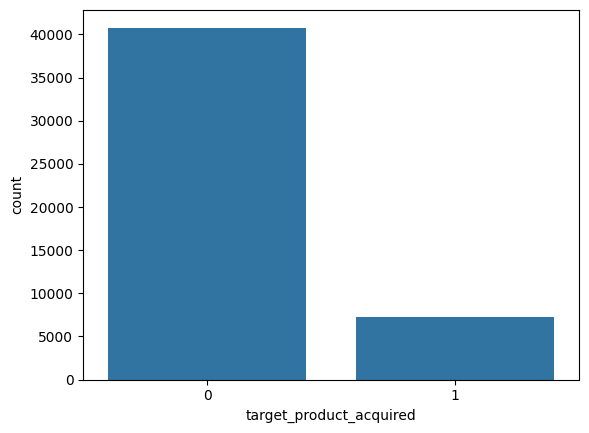

In [8]:
sns.countplot(x='target_product_acquired', data=df_dummies)

In [9]:
df_dummies.groupby('target_product_acquired').size()

target_product_acquired
0    40798
1     7202
dtype: int64

# 2- Ingenieria de variables

### 2.1 - Nuevas variables
Tenemos 3 variables categoricas que debemos transformar . Para esto, vamos a usar la función get_dummies de pandas, que nos va a crear una columna por cada valor único de la variable string, y va a poner un 1 en la columna correspondiente al valor de la variable categorica, y un 0 en las demás columnas.



In [10]:
missing_pct = (
    df_dummies.isna()
              .mean()
              .sort_values(ascending=False)
              * 100
)

print(missing_pct.head(20))

customer_lifetime_value                  25.002083
cross_sell_score                         24.991667
total_international_amount_last_month    24.952083
savings_growth_rate_last_6_months        15.154167
email_click_rate_last_3_months           15.127083
balance_volatility                       15.112500
email_open_rate_last_3_months            15.058333
investment_balance                       15.002083
sms_response_rate_last_3_months          14.985417
num_transactions_last_month               5.156250
savings_balance                           5.047917
credit_score                              5.014583
avg_transaction_amount_last_month         4.900000
income                                    4.887500
checking_balance                          4.881250
num_products                              0.000000
tenure_months                             0.000000
age                                       0.000000
has_savings_account                       0.000000
owns_home                      

In [11]:
df_dummies.describe()

,age,income,credit_score,tenure_months,num_products,has_savings_account,has_checking_account,has_credit_card,has_mortgage,has_personal_loan,...,has_auto_pay_setup,num_failed_transactions_last_month,savings_growth_rate_last_6_months,cross_sell_score,risk_score,customer_lifetime_value,recency_score,frequency_score,monetary_score,target_product_acquired
count,48000.000000,45654.000000,45593.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,...,48000.000000,48000.000000,40726.000000,36004.000000,48000.000000,3.599900e+04,48000.000000,48000.000000,48000.000000,48000.000000
mean,45.965688,43480.151914,649.391024,60.105271,2.410167,0.597083,0.797500,0.503021,0.306146,0.200021,...,0.496917,0.122542,0.020135,28.441461,28.531284,1.309364e+05,59.764628,60.015240,59.984131,0.150042
std,16.485993,28586.183527,98.002006,33.978167,1.245644,0.490489,0.401867,0.499996,0.460896,0.400020,...,0.499996,0.385880,0.099544,15.921789,15.974513,1.289513e+05,20.072050,19.984113,20.018818,0.357116
min,18.000000,3390.020471,300.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-0.412560,0.095670,0.049396,2.020263e+02,1.715713,0.604312,0.768316,0.000000
25%,32.000000,24161.536656,583.977720,31.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-0.047136,15.968122,16.055138,4.407097e+04,45.339714,45.658328,45.640803,0.000000
50%,46.000000,35989.770961,650.416982,60.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.020113,26.424836,26.423108,9.600001e+04,61.143751,61.370692,61.450525,0.000000
75%,60.000000,54522.888378,718.020159,89.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,0.087223,38.719712,38.985152,1.744852e+05,75.463892,75.601976,75.627799,0.000000
max,74.000000,292471.040924,850.000000,119.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,0.491126,96.392718,90.630047,1.670952e+06,99.754061,99.560231,99.930901,1.000000


In [12]:
df_dummies.loc[
    df_dummies['customer_lifetime_value'].isna(),
    ['income','tenure_months']
].isna().sum()

income           586
tenure_months      0
dtype: int64

In [13]:
#Inputamos la media a la columna income
df_dummies['income'] = (
    df_dummies['income']
    .fillna(df_dummies['income'].median())
)

In [14]:
#inputamos la media a la columna balances
df_dummies['savings_balance'] = (
    df_dummies['savings_balance']
    .fillna(df_dummies['savings_balance'].median())
)

In [15]:
df_dummies['credit_card_balance'] = (
    df_dummies['credit_card_balance']
    .fillna(df_dummies['credit_card_balance'].median())
)

In [16]:
(df_dummies['credit_card_balance'] == 0).mean() * 100

np.float64(49.69791666666667)

In [17]:
corr_customer = df_dummies.corr(numeric_only=False)["customer_lifetime_value"].sort_values(ascending=False).to_frame()
corr_customer = corr_customer.drop("customer_lifetime_value", axis=0)
corr_customer = corr_customer.sort_values(["customer_lifetime_value"], ascending=False) # ordenamos en forma descendente
corr_customer = corr_customer
corr_customer

,customer_lifetime_value
income,0.649718
tenure_months,0.576450
target_product_acquired,0.234433
owns_home,0.015357
education_level_bachelor,0.014878
...,...
education_level_master,-0.014095
age,-0.014459
credit_score,-0.017846
debt_to_income_ratio,-0.084501


In [18]:
df_dummies['credit_score'] = (
    df_dummies['credit_score']
    .fillna(df_dummies['credit_score'].median())
)

In [19]:
missing_pct = (
    df_dummies.isna()
              .mean()
              .sort_values(ascending=False)
              * 100
)

print(missing_pct.head(20))

customer_lifetime_value                  25.002083
cross_sell_score                         24.991667
total_international_amount_last_month    24.952083
savings_growth_rate_last_6_months        15.154167
email_click_rate_last_3_months           15.127083
balance_volatility                       15.112500
email_open_rate_last_3_months            15.058333
investment_balance                       15.002083
sms_response_rate_last_3_months          14.985417
num_transactions_last_month               5.156250
avg_transaction_amount_last_month         4.900000
checking_balance                          4.881250
income                                    0.000000
age                                       0.000000
has_savings_account                       0.000000
num_products                              0.000000
tenure_months                             0.000000
credit_score                              0.000000
savings_balance                           0.000000
has_credit_card                

C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\1022970238.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_dummies["income"], kde = False, color = "skyblue",ax=axes[0, 0]) # axes [fila,columna] indica la posición del histograma
C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\1022970238.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwa

<Axes: xlabel='credit_score'>

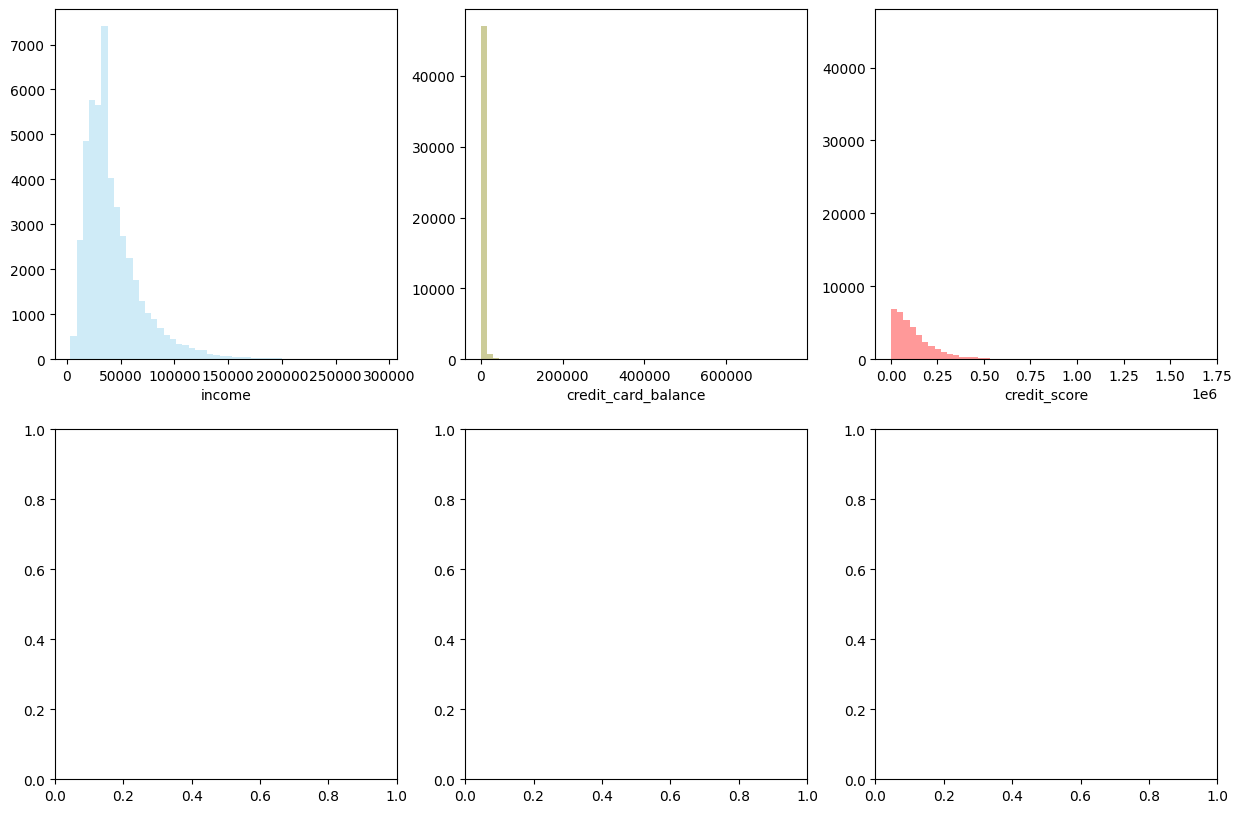

In [20]:
# Construimos un histograma múltiple
f, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=False)

sns.distplot(df_dummies["income"], kde = False, color = "skyblue",ax=axes[0, 0]) # axes [fila,columna] indica la posición del histograma
sns.distplot(df_dummies["credit_card_balance"],kde = False, color = "olive", ax=axes[0, 1])
sns.distplot(df_dummies["customer_lifetime_value"],kde = False, color = "red", ax=axes[0, 2])
sns.distplot(df_dummies["debt_to_income_ratio"],kde = False, color = "red", ax=axes[0, 2])
sns.distplot(df_dummies["credit_score"],kde = False, color = "red", ax=axes[0, 2])


#### **Valores Outliers**

Analicemos la información de cada atributo para analizar posibles outliers.

- **credit_card_balance**



C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\3489119860.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="credit_card_balance", data=df_dummies, orient = 'h', palette="Set2")


<Axes: xlabel='credit_card_balance'>

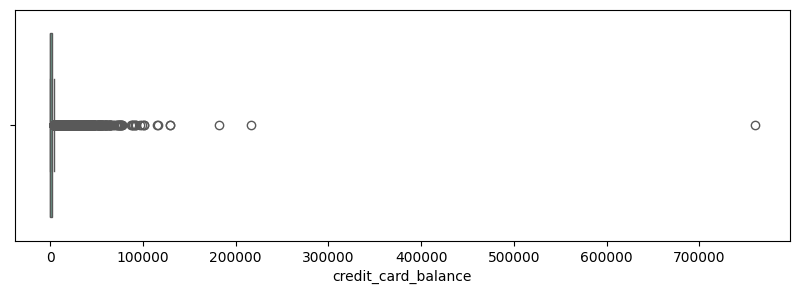

In [21]:
# Creamos un gráfico boxplot para analizar la variable "PREGNANCIES"
plt.figure(figsize=(10, 3))
sns.boxplot(x="credit_card_balance", data=df_dummies, orient = 'h', palette="Set2")

- **investment_balance**

C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\2196926514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="investment_balance", data=df_dummies, orient = 'h', palette="Set2");


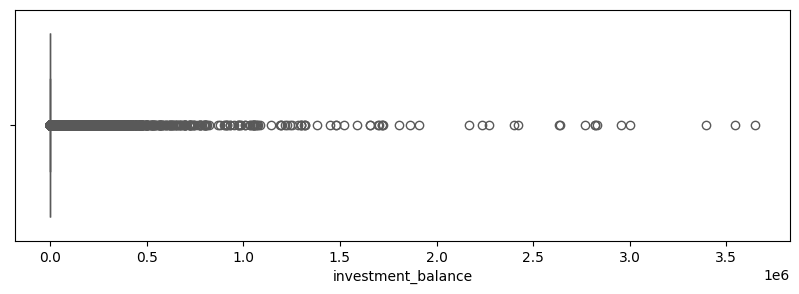

In [22]:
plt.figure(figsize=(10, 3))
sns.boxplot(x="investment_balance", data=df_dummies, orient = 'h', palette="Set2");

C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\187710347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="num_products_purchased_last_year", data=df_dummies, orient = 'h', palette="Set2")


<Axes: xlabel='num_products_purchased_last_year'>

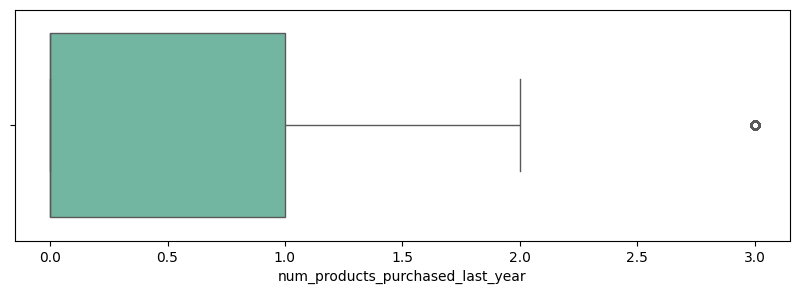

In [23]:
plt.figure(figsize=(10, 3))
sns.boxplot(x="num_products_purchased_last_year", data=df_dummies, orient = 'h', palette="Set2")

C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\3496596985.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="age", data=df_dummies, orient = 'h', palette="Set2")


<Axes: xlabel='age'>

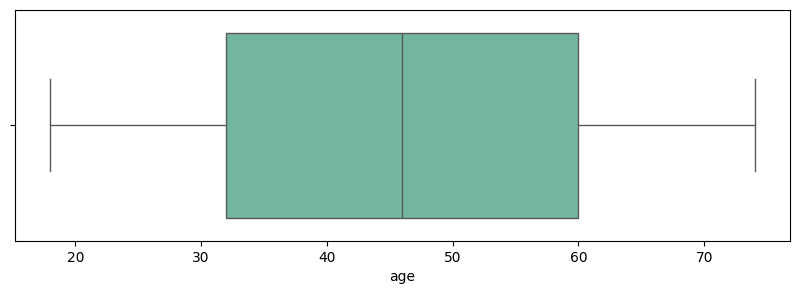

In [24]:
plt.figure(figsize=(10, 3))
sns.boxplot(x="age", data=df_dummies, orient = 'h', palette="Set2")

C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\3869320069.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="income", data=df_dummies, orient = 'h', palette="Set2")


<Axes: xlabel='income'>

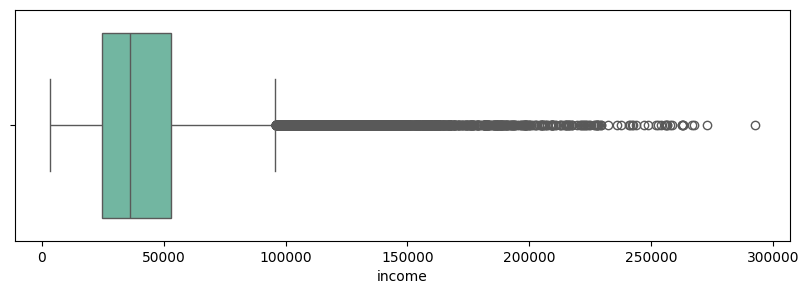

In [25]:
plt.figure(figsize=(10, 3))
sns.boxplot(x="income", data=df_dummies, orient = 'h', palette="Set2")



C:\Users\ditom\AppData\Local\Temp\ipykernel_15488\342165233.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_dummies['income'], shade=True)


<Axes: xlabel='income', ylabel='Density'>

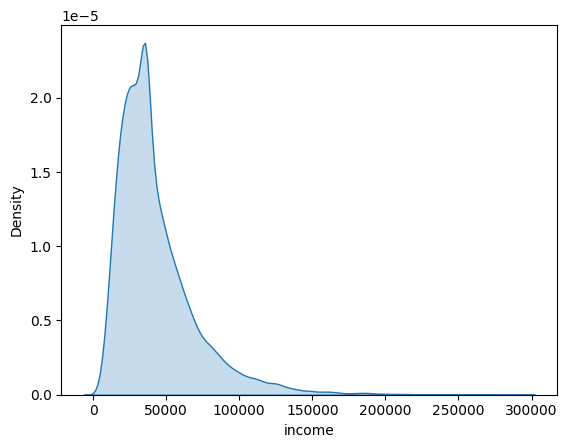

In [26]:
# Distribución de la variable "BloodPressure"
sns.kdeplot(df_dummies['income'], shade=True)

### Análisis de correlación de variables general

In [27]:
corr_gral = df_dummies.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_gral, dtype=bool))

pares_fuertes = (
    corr_gral.mask(mask)
        .stack()
        .reset_index()
)

pares_fuertes.columns = ['Variable_1', 'Variable_2', 'Correlacion']

pares_fuertes = pares_fuertes[
    pares_fuertes['Correlacion'].abs() > 0.5
].sort_values(
    by='Correlacion',
    key=abs,
    ascending=False
)

print(pares_fuertes)

                             Variable_1                           Variable_2  \
3194     total_overdraft_fees_last_year             num_overdrafts_last_year   
2953                avg_monthly_balance                      savings_balance   
1561  avg_transaction_amount_last_month  total_transaction_amount_last_month   
2535               debt_to_income_ratio                  credit_card_balance   
4543              marital_status_single               marital_status_married   
3711            customer_lifetime_value                               income   
2555               debt_to_income_ratio                   credit_utilization   
2839     email_click_rate_last_3_months        email_open_rate_last_3_months   
2465                 credit_utilization                  credit_card_balance   
4756        education_level_high_school             education_level_bachelor   
3713            customer_lifetime_value                        tenure_months   
4188          employment_status_retired 

In [28]:
# Matriz de correlación
corr_target = df_dummies.corr(numeric_only=False)["target_product_acquired"].sort_values(ascending=False).to_frame()
corr_target = corr_target.drop("target_product_acquired", axis=0)
corr_target = corr_target.sort_values(["target_product_acquired"], ascending=False) # ordenamos en forma descendente
corr_target = corr_target
corr_target

,target_product_acquired
income,0.351806
customer_lifetime_value,0.234433
has_investment_account,0.140154
credit_card_balance,0.127331
avg_monthly_balance,0.114591
...,...
num_bill_payments_last_month,-0.005918
has_direct_deposit,-0.006022
risk_score,-0.006793
num_late_payments_last_year,-0.007479


## Correlacion con la variable target

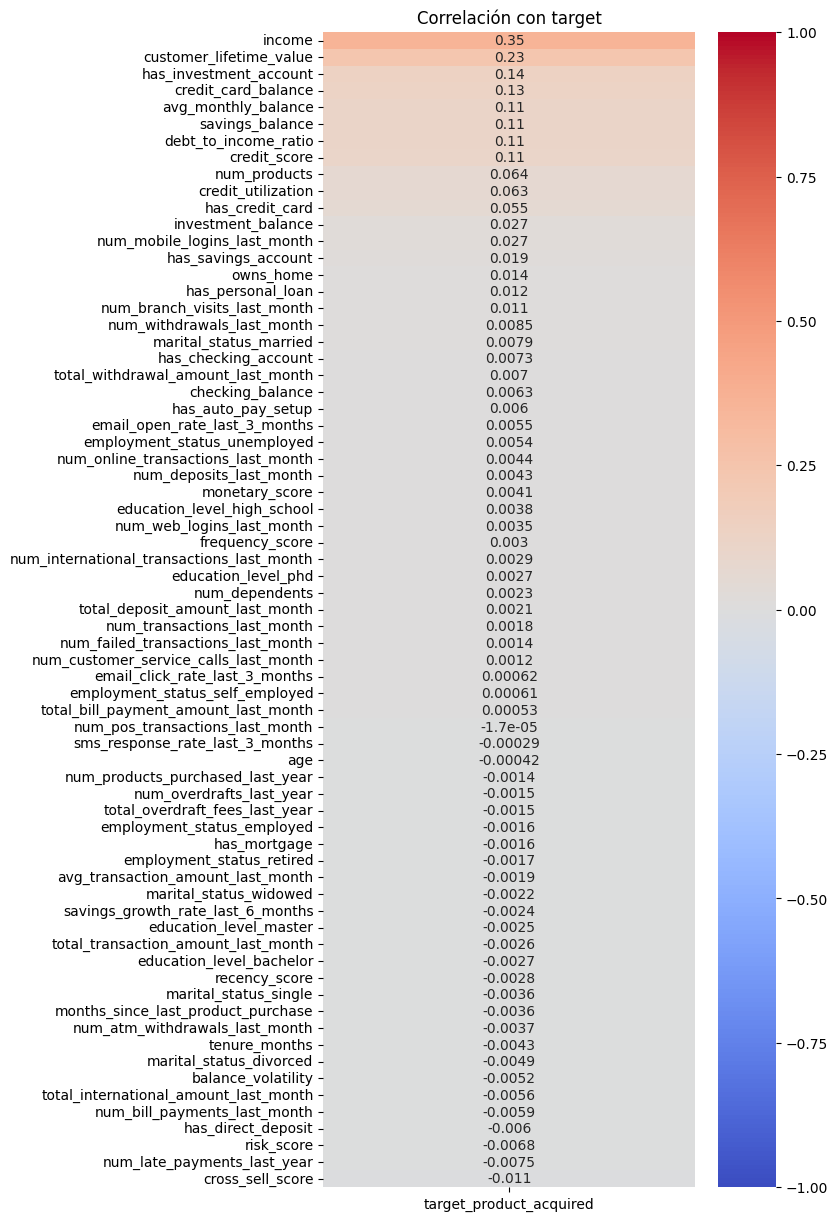

In [29]:
plt.figure(figsize=(6,15))
sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)
plt.title('Correlación con target')
plt.show()

Del mapa de calor podemos observar que las variables con mayor correlación con la variable objetivo "target_product_acquired" que vamos a considerar son aquellas con correlacion > 0.1 que son 
income, customer_lifetime_value,has_investment_account,credit_card_balance,avg_monthly_balance,savings_balance,debt_to_income_ratio,credit_score

## Modelo Base



In [30]:



numeric_features = [
    'income',
    'customer_lifetime_value',
]


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
    ],
    remainder='drop'
)

model_base = Pipeline([
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])



X_base = df_original[numeric_features]
y_base = df_original['target_product_acquired']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.3,
    stratify=y_base,
    random_state=42
)

model_base.fit(X_train_base, y_train_base)



model_base.fit(X_test_base, y_test_base)

y_prob_base = model_base.predict_proba(X_test_base)[:,1]

y_pred_base = model_base.predict(X_test_base)


roc = roc_auc_score(y_test_base, y_prob_base)

print(f" ROC={roc:.4f}")


print(classification_report(y_test_base, y_pred_base ))

 ROC=0.7081
              precision    recall  f1-score   support

           0       0.90      0.76      0.83     12239
           1       0.29      0.55      0.38      2161

    accuracy                           0.73     14400
   macro avg       0.60      0.65      0.60     14400
weighted avg       0.81      0.73      0.76     14400



# 3 - Modelo Final

In [31]:


numeric_features = [
    'income',
    'customer_lifetime_value',
    'credit_card_balance',
    'debt_to_income_ratio',
    'credit_score',
    'avg_monthly_balance',
    'savings_balance',

]


binary_features = [
    'has_investment_account',
    'has_credit_card',
    'has_savings_account',
    'owns_home',
    'has_personal_loan',
    'has_checking_account'
]

categorical_features = [
  'employment_status', 'marital_status', 'education_level'
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features),
    ],
    remainder='drop'
)




model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

In [32]:
from sklearn.model_selection import train_test_split

X = df_original.drop(columns=['target_product_acquired'])
y = df_original['target_product_acquired']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](62,)","['customer_id','snapshot_date','age',...,'recency_score','frequency_score', 'monetary_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,62
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

#### Entrenamos el modelo

In [33]:


model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)

print(f" ROC={roc:.4f}")

 ROC=0.7994


####  Predicts

In [34]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

confusion_matrix(y_test, y_pred)
pd.crosstab(y_test, y_pred, rownames=['Real'], colnames=['Predicho'])

Predicho,0,1
Real,,
0,9269,2970
1,681,1480


#### Importancia de las variables

In [35]:
feature_names = (
    model.named_steps['preprocessor']
         .get_feature_names_out()
)
importancias = pd.DataFrame({
    'Atributo': feature_names,
    'Importancia': abs(
        model.named_steps['classifier'].coef_[0]
    )
})

importancias.sort_values(
    'Importancia',
    ascending=False
).head(15)


,Atributo,Importancia
16,bin__has_investment_account,1.053723
0,num__income,0.964043
3,num__debt_to_income_ratio,0.563496
20,bin__has_personal_loan,0.452337
4,num__credit_score,0.422178
5,num__avg_monthly_balance,0.230099
9,cat__employment_status_unemployed,0.182123
6,num__savings_balance,0.108113
17,bin__has_credit_card,0.075484
1,num__customer_lifetime_value,0.068658


In [36]:
print(y_test.value_counts(normalize=True))

target_product_acquired
0    0.849931
1    0.150069
Name: proportion, dtype: float64


In [37]:

# Reporte del clasificador

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.76      0.84     12239
           1       0.33      0.68      0.45      2161

    accuracy                           0.75     14400
   macro avg       0.63      0.72      0.64     14400
weighted avg       0.84      0.75      0.78     14400



In [38]:


y_prob = model.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, y_prob))

0.7994460475402008


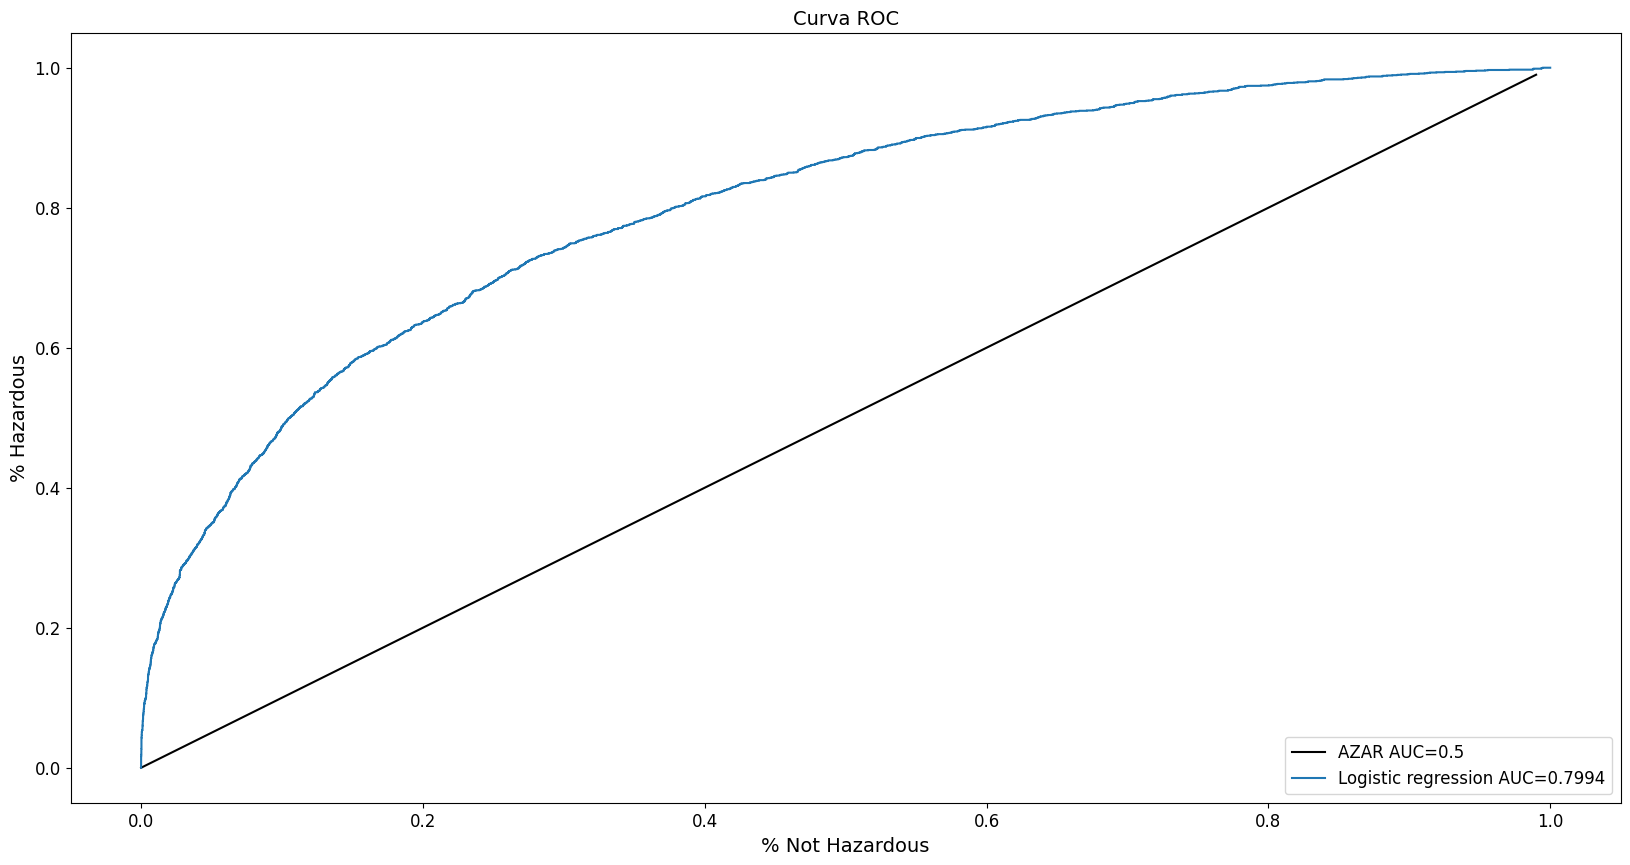

In [39]:
def graficarCurvaRoc( y_pred, model ):
  fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
  auc = metrics.roc_auc_score(y_test, y_pred)
  # Graficamos
  plt.plot(fpr,tpr,label= model +" AUC="+str(round(auc,4))) #,label= "AUC="+str(auc))
  plt.legend(loc=4, fontsize=12)
  return auc

# Inicializamos los labels del gráfico
plt.figure(figsize=(20, 10))
plt.xlabel('% Not Hazardous', fontsize=14)
plt.ylabel('% Hazardous', fontsize=14)

# Graficamos la recta del azar
it = [i/100 for i in range(100)]
plt.plot(it,it,label="AZAR AUC=0.5",color="black")

modelos = {'Logistic regression':y_prob}
for pred in modelos:
    auc = graficarCurvaRoc( modelos[pred] , pred )

# Agregamos el titulo y configuro el tamaño de letra
plt.title("Curva ROC", fontsize=14)
plt.tick_params(labelsize=12);
plt.show()

In [40]:
df_nuevos_clientes = pd.read_csv('bank_product_propensity_predict.csv', sep = ',');

probabilidades = model.predict_proba(df_nuevos_clientes)[:,1]


In [41]:
prediccion = model.predict(df_nuevos_clientes)

df_resultado = pd.DataFrame({
    'customer_id': df_nuevos_clientes['customer_id'],
    'prob_adquirir_producto': probabilidades,
    'prediccion': prediccion
})

df_resultado = df_resultado.sort_values(
    by='prob_adquirir_producto',
    ascending=False
)



df_resultado.to_csv(
    'predicciones_producto.csv',
    index=False
)


# 4 - Resumen

## Tabla comparacion rendimiento modelo base vs final

### Modelo Base

 ROC=0.7081

|  | precision |recall | f1-score |  support|
|--------|-----------|-------|--------- |--------|
| 0      | 0.90 |     0.76  |    0.83   |  12239|
| 1      | 0.29 |     0.55  |    0.38   |   2161|
|accuracy|      |           |   0.73    | 14400|
|macro avg | 0.60 | 0.65    | 0.60 |    |14400|
|weighted avg   | 0.81   | 0.73   |0.76 | 14400|


### Modelo Final

ROC=0.7994


|| precision    |recall  |f1-score  | support|
|--------------|--------|----------|--------|---------|
| 0     |  0.93     | 0.76     | 0.84     |12239|
| 1      | 0.33    |  0.68     | 0.45     | 2161|
|accuracy |            |         |     0.75  |   14400|
|macro avg |      0.63 |     0.72|      0.64 |    14400|
|weighted avg|       0.84     | 0.75      |0.78     |14400|

## Insights clave

- Los clientes con mayores ingresos y valor de vida en dolares tienen alta probabilidad de adquirir el nuevo producto
- Los clientes que tienen ya tienen distintos productos adquiridos tambien presentan propension a adquirir el nuevo producto

## Recomendaciones de Negocio

- Piorizar acciones comerciales apuntadas a los clientes que tienen mas probabilidad de adquirir el nuevo producto
- Personalizar oferta de productos segun las distintas segmentaciones
